# 03 GTFS Exploratory Data Analysis

This notebook is prepared for the TTC Capstone Project GTFS/GTFC dataset workflow.

## Purpose

This notebook explores the GTFS feature-engineered datasets and creates summary tables and visualizations for the TTC capstone project.

This notebook generates EDA tables and visualizations for GTFS-based TTC service analysis. The outputs are used to examine scheduled service patterns, route characteristics, operational coverage, and service supply indicators across TTC routes.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Find project root automatically
PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / ".git").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root found at: {PROJECT_ROOT}")

INPUT_DIR = PROJECT_ROOT / "data"
TABLE_DIR = INPUT_DIR / "external" / "eda_outputs" / "gtfs_eda_tables"


TABLE_DIR.mkdir(parents=True, exist_ok=True)

route_features = pd.read_csv(INPUT_DIR / "processed" / "cleaned_ttc_routes_and_schedules" / "gtfs_route_service_feature.csv")
trip_features = pd.read_csv(INPUT_DIR / "processed" / "cleaned_ttc_routes_and_schedules" / "gtfs_trip_service_feature.csv")
stop_features = pd.read_csv(INPUT_DIR / "processed" / "cleaned_ttc_routes_and_schedules" / "gtfs_stop_service_features.csv")

print("route_features:", route_features.shape)
print("trip_features:", trip_features.shape)
print("stop_features:", stop_features.shape)

Project root found at: /Users/keerthirohith/Desktop/UNF/MDA/Term 5/Capstone-Project-Group-5-ttc-service-reliability-analysis
route_features: (231, 8)
trip_features: (134882, 16)
stop_features: (9378, 14)


In [3]:
# -----------------------------
# Summary statistics
# -----------------------------
route_summary = route_features.describe(include="all")
route_summary.to_csv(TABLE_DIR / "gtfs_route_summary_statistics.csv")
route_summary

,route_id,route_short_name,total_scheduled_trips,avg_stops_per_trip,max_stops_per_trip,avg_trip_duration_minutes,max_trip_duration_minutes,number_of_service_ids
count,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000,231.000000
mean,252.285714,252.285714,583.904762,31.822041,37.324675,32.893958,44.986147,3.887446
std,288.555120,288.555120,485.348113,15.508287,20.637519,15.805125,22.463756,1.228420
min,1.000000,1.000000,2.000000,3.006557,4.000000,8.030303,8.400000,1.000000
25%,61.500000,61.500000,222.000000,18.819405,20.000000,20.945385,29.000000,4.000000
50%,120.000000,120.000000,450.000000,29.833663,33.000000,30.421687,40.000000,4.000000
75%,339.500000,339.500000,828.500000,42.260476,49.500000,43.476983,60.000000,4.000000
max,996.000000,996.000000,2533.000000,78.605263,132.000000,93.155980,129.000000,8.000000


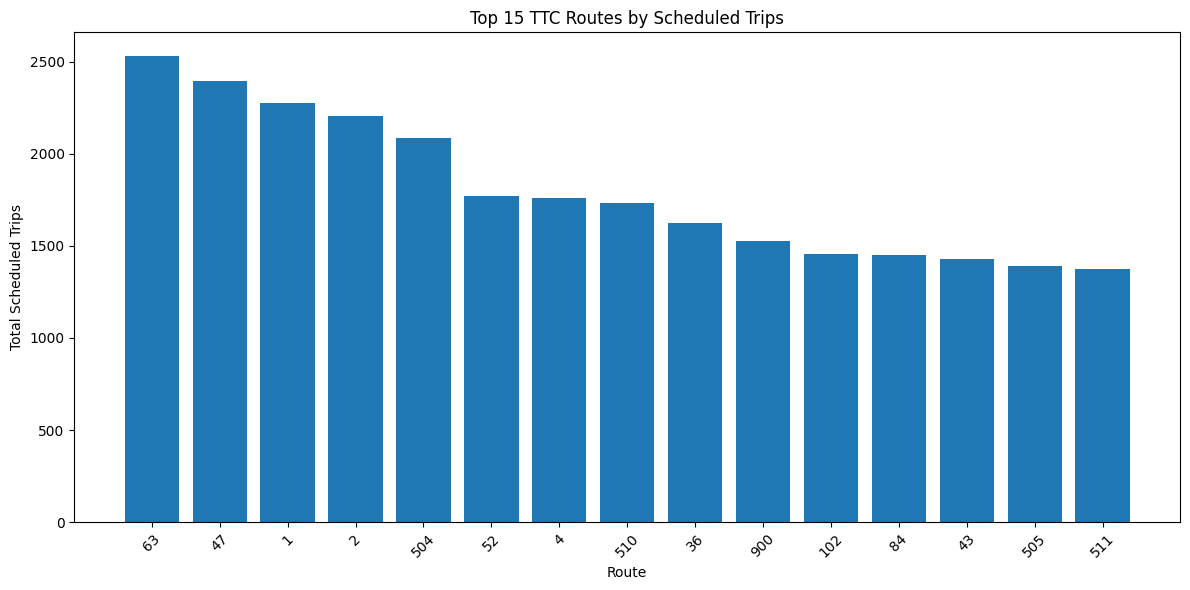

In [4]:
# -----------------------------
# Top routes by scheduled trips
# -----------------------------
top_routes_by_trips = route_features.sort_values("total_scheduled_trips", ascending=False).head(15)
top_routes_by_trips.to_csv(TABLE_DIR / "top_15_routes_by_scheduled_trips.csv", index=False)

plt.figure(figsize=(12, 6))
plt.bar(top_routes_by_trips["route_short_name"].astype(str), top_routes_by_trips["total_scheduled_trips"])
plt.xlabel("Route")
plt.ylabel("Total Scheduled Trips")
plt.title("Top 15 TTC Routes by Scheduled Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

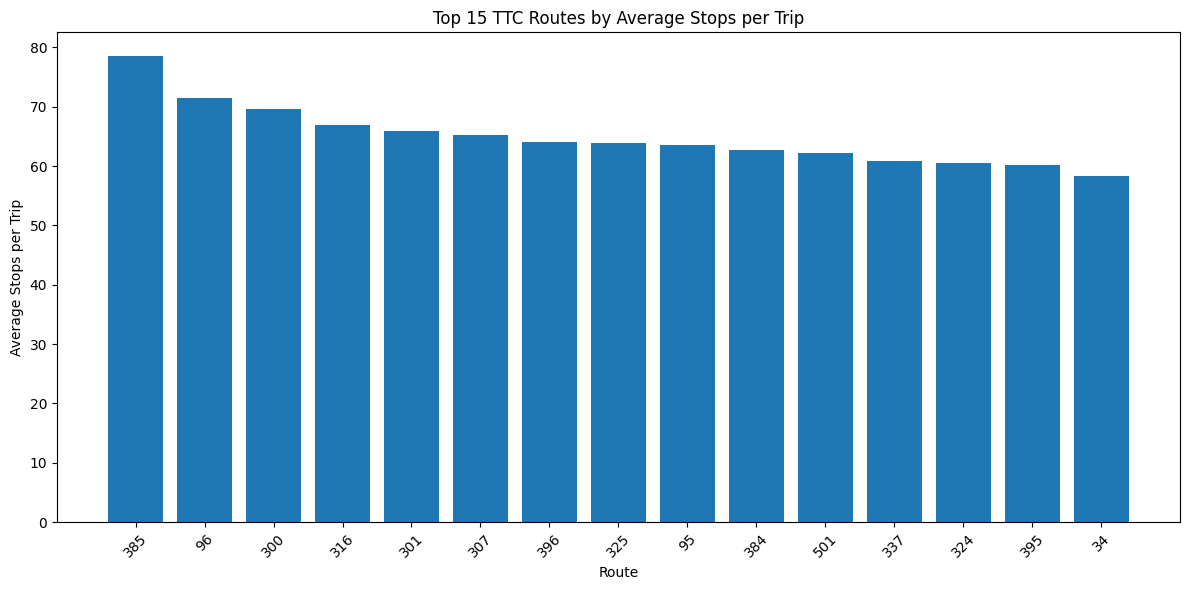

In [5]:
# -----------------------------
# Top routes by average stops per trip
# -----------------------------
top_routes_by_stops = route_features.sort_values("avg_stops_per_trip", ascending=False).head(15)
top_routes_by_stops.to_csv(TABLE_DIR / "top_15_routes_by_avg_stops.csv", index=False)

plt.figure(figsize=(12, 6))
plt.bar(top_routes_by_stops["route_short_name"].astype(str), top_routes_by_stops["avg_stops_per_trip"])
plt.xlabel("Route")
plt.ylabel("Average Stops per Trip")
plt.title("Top 15 TTC Routes by Average Stops per Trip")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

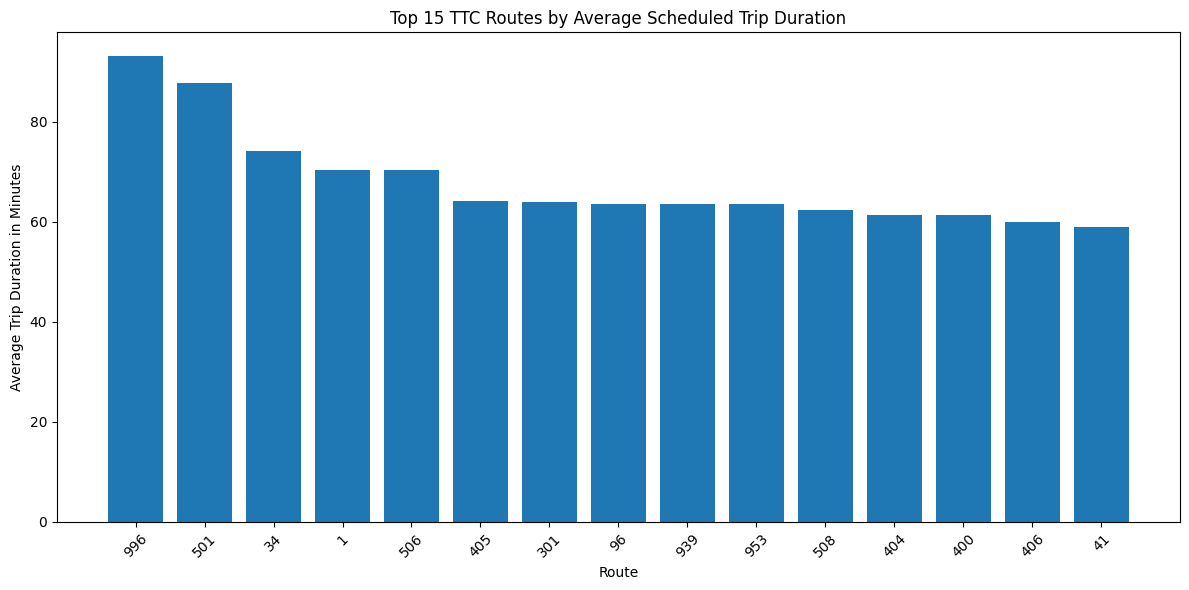

In [6]:
# -----------------------------
# Top routes by average scheduled trip duration
# -----------------------------
top_routes_by_duration = route_features.sort_values("avg_trip_duration_minutes", ascending=False).head(15)
top_routes_by_duration.to_csv(TABLE_DIR / "top_15_routes_by_avg_duration.csv", index=False)

plt.figure(figsize=(12, 6))
plt.bar(top_routes_by_duration["route_short_name"].astype(str), top_routes_by_duration["avg_trip_duration_minutes"])
plt.xlabel("Route")
plt.ylabel("Average Trip Duration in Minutes")
plt.title("Top 15 TTC Routes by Average Scheduled Trip Duration")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

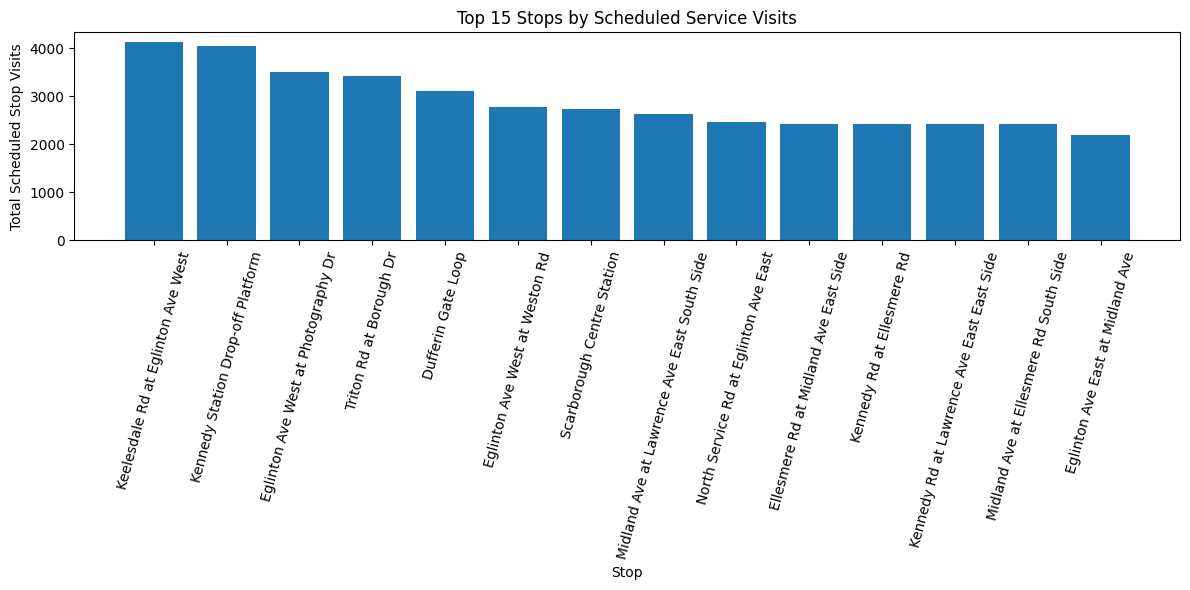

In [7]:
# -----------------------------
# Top stops by scheduled service visits
# -----------------------------
top_stops = stop_features.sort_values("total_stop_visits", ascending=False).head(15)
top_stops.to_csv(TABLE_DIR / "top_15_stops_by_service_visits.csv", index=False)

label_col = "stop_name" if "stop_name" in top_stops.columns else "stop_id"

plt.figure(figsize=(12, 6))
plt.bar(top_stops[label_col].astype(str), top_stops["total_stop_visits"])
plt.xlabel("Stop")
plt.ylabel("Total Scheduled Stop Visits")
plt.title("Top 15 Stops by Scheduled Service Visits")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()